<div style="background-color:#4CAF50; padding:8px 14px; border-radius:4px;">
<h2 style="color:black; margin:0;">Analysis</h2>
</div>

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Import Libraries</h3>
</div>

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from copy import copy

from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.special import erf
from pathlib import Path
from numpy.fft import fft, ifft

from datetime import datetime
import json

#import ipywidgets as widgets
from IPython.display import display
from collections import defaultdict

<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Load Data</h3>
</div>

In [12]:
base_dir = Path(r"C:\Users\hlab_\Box\Henriksen Lab Data\DefectMsmts\Data\Convolution_Msmnts")
spd_run_numbers = range(209, 210)  # 198-199 inclusive
spd_runs = {}
for run_num in spd_run_numbers:
    matches = list(base_dir.glob(f"*_{run_num}"))
    if not matches:
        print(f"no folder found for run {run_num}")
        continue
    folder = matches[0]

    npz_path = folder / "data.npz"
    data = np.load(npz_path)

    metadata_path = folder / "metadata.json"
    with open(metadata_path) as f:
        metadata = json.load(f)

    spd_runs[run_num] = {
        "data": data,
        "metadata": metadata,
        "folder": folder,
    }
    print(f"loaded run {run_num}: {folder.name}")

loaded run 209: 20260715163748_209


<div style="background-color:#2196F3; padding:8px 14px; border-radius:4px;">
<h3 style="color:black; margin:0;">Analyze</h3>
</div>

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Plot Raw Data</h4>
</div>

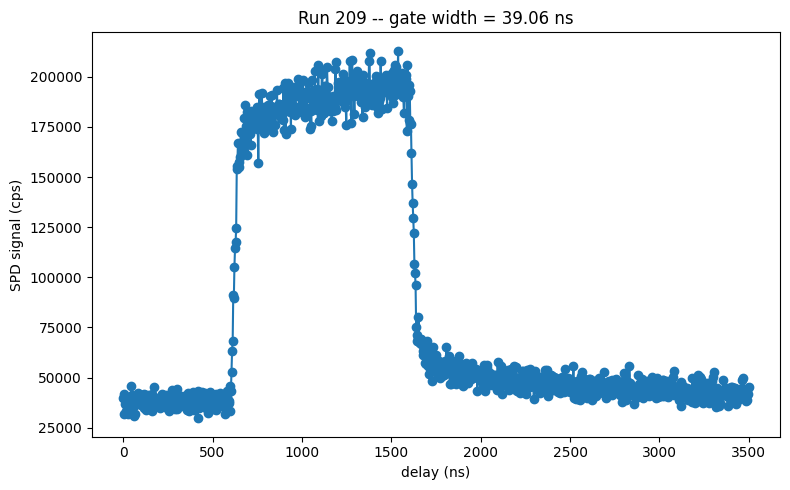

In [18]:
run_num = 209
t = spd_runs[run_num]["data"]["delays_ns"]
counts_mean = spd_runs[run_num]["data"]["counts_mean"]
gate_width = spd_runs[run_num]["metadata"]["gate_width_tns"]

gate_width_s = gate_width * 1e-9
y = counts_mean / gate_width_s   # now genuinely cps, matching the original plot

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, y, 'o-')
ax.set_xlabel('delay (ns)')
ax.set_ylabel('SPD signal (cps)')
ax.set_title(f'Run {run_num} -- gate width = {gate_width:.2f} ns')
plt.tight_layout()
plt.show()

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Fit Function</h4>
</div>

In [6]:
def double_erf_step(t, baseline, amp1, t0_1, sigma1, amp2, t0_2, sigma2):
    fast = amp1 * 0.5 * (1 + erf((t - t0_1) / (sigma1 * np.sqrt(2))))
    slow = amp2 * 0.5 * (1 + erf((t - t0_2) / (sigma2 * np.sqrt(2))))
    return baseline + fast + slow

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Plot Fit</h4>
</div>

<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Noise Analysis</h5>
</div>

In [8]:
def find_settled_regions(t, y, buffer_ns_rise=60, buffer_ns_fall=400, smooth_window_ns=20):
    t = np.asarray(t)
    y = np.asarray(y)
    dt = np.median(np.diff(t))
    smooth_pts = max(1, int(round(smooth_window_ns / dt)))

    kernel = np.ones(smooth_pts) / smooth_pts
    y_smooth = np.convolve(y, kernel, mode='same')

    thresh = (y_smooth.max() + y_smooth.min()) / 2
    above = y_smooth > thresh
    high_idxs = np.where(above)[0]
    rise_idx = high_idxs[0]
    fall_idx = high_idxs[-1]

    buffer_pts_rise = int(round(buffer_ns_rise / dt))
    buffer_pts_fall = int(round(buffer_ns_fall / dt))

    plateau_start = rise_idx + buffer_pts_rise
    plateau_end = fall_idx - buffer_pts_rise  # still using rise-side buffer for the plateau's own leading edge into the fall

    plateau_mask = np.zeros_like(t, dtype=bool)
    plateau_mask[plateau_start:plateau_end] = True

    baseline_mask = np.zeros_like(t, dtype=bool)
    baseline_mask[:rise_idx - buffer_pts_rise] = True
    baseline_mask[fall_idx + buffer_pts_fall:] = True  # bigger buffer here to clear the decay tail

    excluded_mask = ~(plateau_mask | baseline_mask)
    return baseline_mask, plateau_mask, excluded_mask


Plot to Find Baseline Markers and Peak Markers

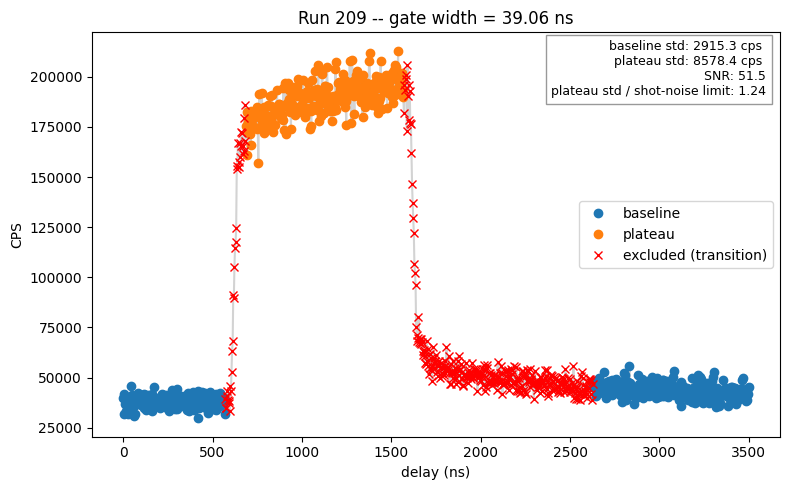

baseline std: 2915.3 cps  plateau std: 8578.4 cps
plateau std / shot-noise limit: 1.24  (1.0 = shot-noise-limited)


In [30]:
baseline_mask, plateau_mask, excluded_mask = find_settled_regions(t, y, buffer_ns_rise=60, buffer_ns_fall=1000, smooth_window_ns=20)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, y, '-', color='lightgray', zorder=1)
ax.plot(t[baseline_mask], y[baseline_mask], 'o', color='tab:blue', label='baseline')
ax.plot(t[plateau_mask], y[plateau_mask], 'o', color='tab:orange', label='plateau')
ax.plot(t[excluded_mask], y[excluded_mask], 'x', color='red', label='excluded (transition)')
ax.legend()
ax.set_xlabel('delay (ns)')
ax.set_ylabel('CPS')
ax.set_title(f'Run {run_num} -- gate width = {gate_width:.2f} ns')

# tight, hand-picked windows for SNR -- away from edges/ringing
baseline_mask_pts = t < 500
plateau_mask_pts = (t > 700) & (t < 1500)

baseline_mean = y[baseline_mask_pts].mean()
plateau_mean = y[plateau_mask_pts].mean()
baseline_std = y[baseline_mask_pts].std()
plateau_std = y[plateau_mask_pts].std()

snr = (plateau_mean - baseline_mean) / baseline_std

# shot-noise check -- needs raw counts, not cps, since Poisson stats apply to counts
counts_mean = spd_runs[run_num]["data"]["counts_mean"]
plateau_counts_mean = counts_mean[plateau_mask_pts].mean()
plateau_std_counts = counts_mean[plateau_mask_pts].std()
reps = spd_runs[run_num]["metadata"]["reps"]
shot_noise_limit = np.sqrt(plateau_counts_mean / reps)
excess_noise_ratio = plateau_std_counts / shot_noise_limit

stats_text = (f"baseline std: {baseline_std:.1f} cps \n"
              f"plateau std: {plateau_std:.1f} cps \n"
              f"SNR: {snr:.1f}\n"
              f"plateau std / shot-noise limit: {excess_noise_ratio:.2f}")
ax.text(0.98, 0.98, stats_text, transform=ax.transAxes,
        ha='right', va='top', fontsize=9,
        bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))

plt.tight_layout()
plt.show()

print(f"baseline std: {baseline_std:.1f} cps  plateau std: {plateau_std:.1f} cps")
print(f"plateau std / shot-noise limit: {excess_noise_ratio:.2f}  (1.0 = shot-noise-limited)")


Save

In [78]:
save_dir = base_dir / "convolution_fits_spd" / "SNR"
save_dir.mkdir(parents=True, exist_ok=True)

fig.savefig(save_dir / f"run{run_num}_gatewidth{gate_width:.2f}ns_SNR.png", dpi=150, bbox_inches='tight')
plt.show()

<div style="background-color:#FFD43B; padding:8px 14px; border-radius:4px;">
<h4 style="color:black; margin:0;">Deconvolution</h4>
</div>

<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Build Kernel</h5>
</div>

In [14]:
run_num = 209
t = spd_runs[run_num]["data"]["delays_ns"]
counts_mean = spd_runs[run_num]["data"]["counts_mean"]
gate_width = spd_runs[run_num]["metadata"]["gate_width_tns"]

dt = np.median(np.diff(t))  # actual sample spacing, ~3.26 ns
kernel_len = max(1, int(round(gate_width / dt)))  # gate width in units of samples

kernel = np.ones(kernel_len) / kernel_len  # boxcar, normalized to sum to 1

print(f"sample spacing: {dt:.3f} ns")
print(f"gate width: {gate_width:.3f} ns -> kernel length: {kernel_len} samples")

sample spacing: 3.258 ns
gate width: 39.062 ns -> kernel length: 12 samples


<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Wiener Deconvolve Function</h5>
</div>

In [16]:

def wiener_deconvolve(signal, kernel, noise_reg=0.01):
    n = len(signal)
    kernel_padded = np.zeros(n)
    kernel_padded[:len(kernel)] = kernel
    kernel_padded = np.roll(kernel_padded, -len(kernel)//2)  # center the kernel

    S = fft(signal)
    K = fft(kernel_padded)

    # Wiener filter: divide, but protect against near-zero K
    K_conj = np.conj(K)
    denom = (K * K_conj) + noise_reg
    recovered = ifft(S * K_conj / denom).real

    return recovered

<div style="background-color:#00FF00; padding:8px 14px; border-radius:4px;">
<h5 style="color:black; margin:0;">Recovered Signal</h5>
</div>

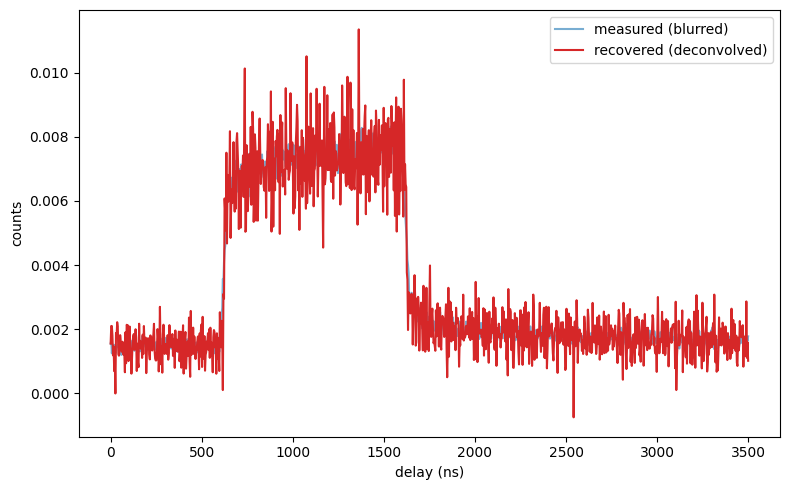

In [17]:
recovered_signal = wiener_deconvolve(counts_mean, kernel, noise_reg=0.01)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(t, counts_mean, label='measured (blurred)', alpha=0.6)
ax.plot(t, recovered_signal, label='recovered (deconvolved)', color='tab:red')
ax.set_xlabel('delay (ns)')
ax.set_ylabel('counts')
ax.legend()
plt.tight_layout()
plt.show()

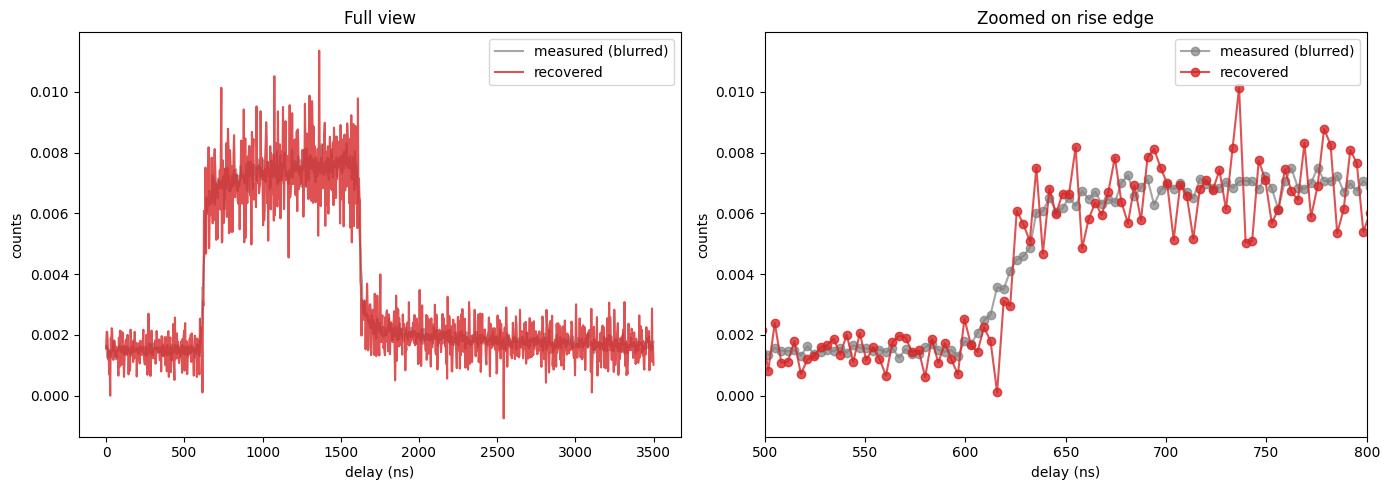

In [23]:
recovered_signal = wiener_deconvolve(counts_mean, kernel, noise_reg=1e-2)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(t, counts_mean, label='measured (blurred)', color='gray', alpha=0.7)
ax[0].plot(t, recovered_signal, label='recovered', color='tab:red', alpha=0.8)
ax[0].set_xlabel('delay (ns)')
ax[0].set_ylabel('counts')
ax[0].legend()
ax[0].set_title('Full view')

# zoom into just the rise edge
ax[1].plot(t, counts_mean, 'o-', label='measured (blurred)', color='gray', alpha=0.7)
ax[1].plot(t, recovered_signal, 'o-', label='recovered', color='tab:red', alpha=0.8)
ax[1].set_xlim(500, 800)
ax[1].set_xlabel('delay (ns)')
ax[1].set_ylabel('counts')
ax[1].legend()
ax[1].set_title('Zoomed on rise edge')

plt.tight_layout()
plt.show()

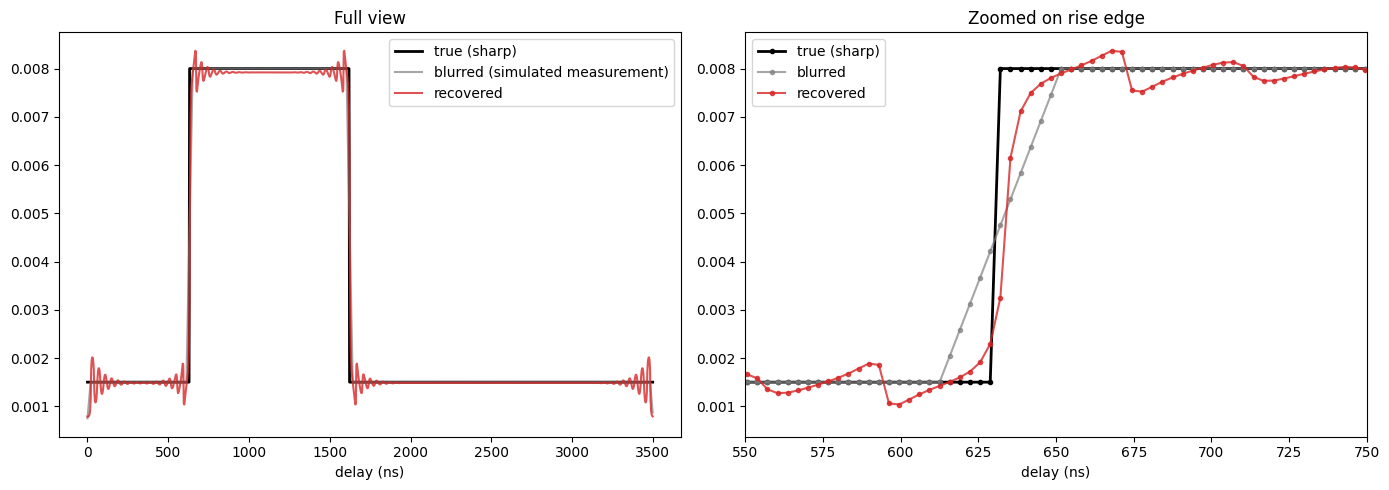

In [24]:
# Synthetic sanity check: does our deconvolution correctly recover
# a known sharp step, given the same kernel, no noise?

t_synth = np.arange(0, 3500, dt)  # same sample spacing as your real data
true_signal = np.where((t_synth > 630) & (t_synth < 1620), 0.008, 0.0015)  # sharp step, matching your rough levels

# blur it with the same kernel your real 39ns gate would apply
blurred_signal = np.convolve(true_signal, kernel, mode='same')

# now try to recover the sharp step back
recovered_synth = wiener_deconvolve(blurred_signal, kernel, noise_reg=1e-2)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].plot(t_synth, true_signal, label='true (sharp)', color='black', linewidth=2)
ax[0].plot(t_synth, blurred_signal, label='blurred (simulated measurement)', color='gray', alpha=0.7)
ax[0].plot(t_synth, recovered_synth, label='recovered', color='tab:red', alpha=0.8)
ax[0].legend()
ax[0].set_title('Full view')
ax[0].set_xlabel('delay (ns)')

ax[1].plot(t_synth, true_signal, 'o-', label='true (sharp)', color='black', linewidth=2, markersize=3)
ax[1].plot(t_synth, blurred_signal, 'o-', label='blurred', color='gray', alpha=0.7, markersize=3)
ax[1].plot(t_synth, recovered_synth, 'o-', label='recovered', color='tab:red', alpha=0.8, markersize=3)
ax[1].set_xlim(550, 750)
ax[1].legend()
ax[1].set_title('Zoomed on rise edge')
ax[1].set_xlabel('delay (ns)')

plt.tight_layout()
plt.show()

In [25]:
# current noise level: std of raw counts in the flat baseline region
baseline_mask_pts = t < 500
current_noise_std = counts_mean[baseline_mask_pts].std()
current_reps = spd_runs[run_num]["metadata"]["reps"]

# step size: plateau minus baseline
plateau_mask_pts = (t > 700) & (t < 1500)
step_size = counts_mean[plateau_mask_pts].mean() - counts_mean[baseline_mask_pts].mean()

current_snr = step_size / current_noise_std
print(f"current per-point noise std: {current_noise_std:.5f}")
print(f"step size: {step_size:.5f}")
print(f"current per-point SNR: {current_snr:.1f}")

# rough target: our synthetic test showed clean recovery once noise stopped
# fighting the correction. As a practical target, aim for noise reduced
# ~15x from where it is now.
target_snr_multiplier = 15
target_reps = current_reps * target_snr_multiplier**2
print(f"target reps for ~{target_snr_multiplier}x cleaner SNR: {target_reps:,.0f}")

current per-point noise std: 0.00011
step size: 0.00587
current per-point SNR: 51.5
target reps for ~15x cleaner SNR: 22,500,000


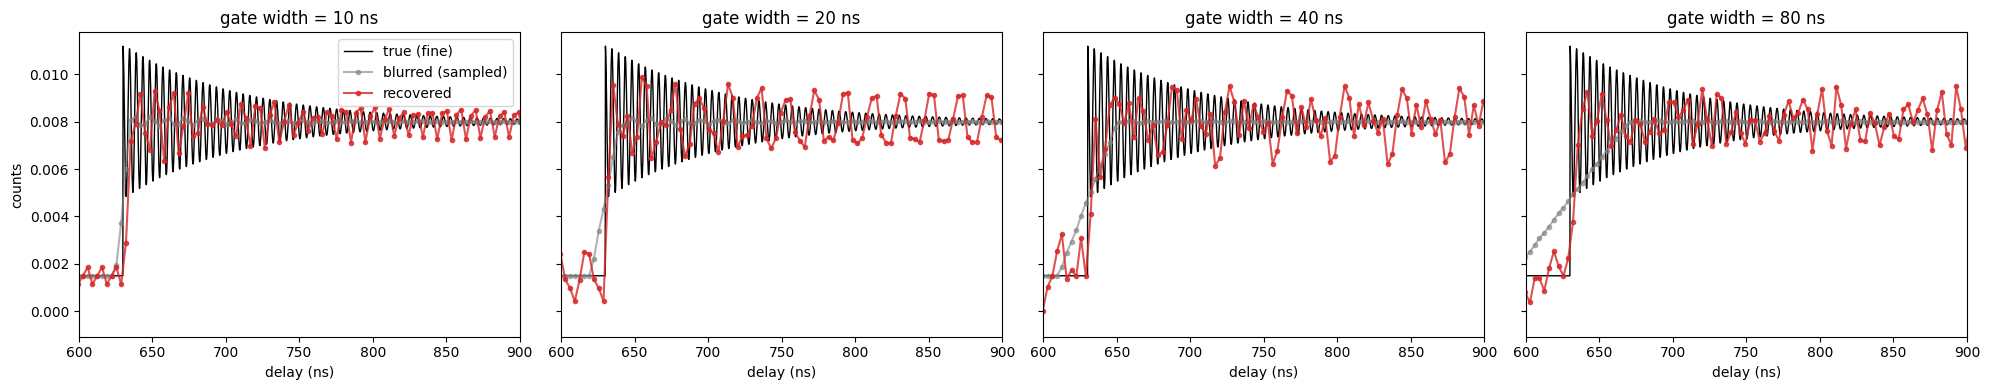

In [27]:
# build "true" signal on a much finer grid than our real hardware can sample
dt_fine = dt / 20  # 20x finer resolution, just for building ground truth
t_fine = np.arange(0, 3500, dt_fine)
true_signal_fine = damped_oscillation(t_fine, ring_freq_ghz=0.22, damping_ns=80)

gate_widths_to_test = [10, 20, 40, 80]
fig, axes = plt.subplots(1, len(gate_widths_to_test), figsize=(20, 4), sharey=True)

for ax, gw in zip(axes, gate_widths_to_test):
    # kernel built at fine resolution, matching this gate width in real ns
    k_len_fine = max(1, int(round(gw / dt_fine)))
    fine_kernel = np.ones(k_len_fine) / k_len_fine

    blurred_fine = np.convolve(true_signal_fine, fine_kernel, mode='same')

    # now downsample to our REAL hardware sample spacing -- this is what we'd actually measure
    sample_idxs = np.arange(0, len(t_fine), int(round(dt / dt_fine)))
    t_sampled = t_fine[sample_idxs]
    blurred_sampled = blurred_fine[sample_idxs]

    # deconvolve using the coarse-resolution kernel (what we actually know from hardware)
    k_len_coarse = max(1, int(round(gw / dt)))
    coarse_kernel = np.ones(k_len_coarse) / k_len_coarse
    recovered = wiener_deconvolve(blurred_sampled, coarse_kernel, noise_reg=1e-8)

    ax.plot(t_fine, true_signal_fine, color='black', label='true (fine)', linewidth=1)
    ax.plot(t_sampled, blurred_sampled, 'o-', color='gray', alpha=0.6, label='blurred (sampled)', markersize=3)
    ax.plot(t_sampled, recovered, 'o-', color='tab:red', alpha=0.8, label='recovered', markersize=3)
    ax.set_xlim(600, 900)
    ax.set_title(f'gate width = {gw} ns')
    ax.set_xlabel('delay (ns)')

axes[0].legend()
axes[0].set_ylabel('counts')
plt.tight_layout()
plt.show()